In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/global-earthquake-tsunami-risk-assessment-dataset/earthquake_data_tsunami.csv


In [2]:
import pandas as pd
df = pd.read_csv('/kaggle/input/global-earthquake-tsunami-risk-assessment-dataset/earthquake_data_tsunami.csv')
df.head()

,magnitude,cdi,mmi,sig,nst,dmin,gap,depth,latitude,longitude,Year,Month,tsunami
0,7.0,8,7,768,117,0.509,17.0,14.000,-9.7963,159.596,2022,11,1
1,6.9,4,4,735,99,2.229,34.0,25.000,-4.9559,100.738,2022,11,0
2,7.0,3,3,755,147,3.125,18.0,579.000,-20.0508,-178.346,2022,11,1
3,7.3,5,5,833,149,1.865,21.0,37.000,-19.2918,-172.129,2022,11,1
4,6.6,0,2,670,131,4.998,27.0,624.464,-25.5948,178.278,2022,11,1


**Data Overview**

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 782 entries, 0 to 781
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   magnitude  782 non-null    float64
 1   cdi        782 non-null    int64  
 2   mmi        782 non-null    int64  
 3   sig        782 non-null    int64  
 4   nst        782 non-null    int64  
 5   dmin       782 non-null    float64
 6   gap        782 non-null    float64
 7   depth      782 non-null    float64
 8   latitude   782 non-null    float64
 9   longitude  782 non-null    float64
 10  Year       782 non-null    int64  
 11  Month      782 non-null    int64  
 12  tsunami    782 non-null    int64  
dtypes: float64(6), int64(7)
memory usage: 79.6 KB


In [7]:
print("\Missing Values ")
df.isnull().sum()

\Missing Values 


magnitude    0
cdi          0
mmi          0
sig          0
nst          0
dmin         0
gap          0
depth        0
latitude     0
longitude    0
Year         0
Month        0
tsunami      0
dtype: int64

In [9]:
print("\nChecking for duplicates ")
df.duplicated()


Checking for duplicates 


0      False
1      False
2      False
3      False
4      False
       ...  
777    False
778    False
779    False
780    False
781    False
Length: 782, dtype: bool

In [5]:
print("\nDescriptive Statistics ")
display(df.describe())


Descriptive Statistics 


,magnitude,cdi,mmi,sig,nst,dmin,gap,depth,latitude,longitude,Year,Month,tsunami
count,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000
mean,6.941125,4.333760,5.964194,870.108696,230.250639,1.325757,25.038990,75.883199,3.538100,52.609199,2012.280051,6.563939,0.388747
std,0.445514,3.169939,1.462724,322.465367,250.188177,2.218805,24.225067,137.277078,27.303429,117.898886,6.099439,3.507866,0.487778
min,6.500000,0.000000,1.000000,650.000000,0.000000,0.000000,0.000000,2.700000,-61.848400,-179.968000,2001.000000,1.000000,0.000000
25%,6.600000,0.000000,5.000000,691.000000,0.000000,0.000000,14.625000,14.000000,-14.595600,-71.668050,2007.000000,3.250000,0.000000
50%,6.800000,5.000000,6.000000,754.000000,140.000000,0.000000,20.000000,26.295000,-2.572500,109.426000,2013.000000,7.000000,0.000000
75%,7.100000,7.000000,7.000000,909.750000,445.000000,1.863000,30.000000,49.750000,24.654500,148.941000,2017.000000,10.000000,1.000000
max,9.100000,9.000000,9.000000,2910.000000,934.000000,17.654000,239.000000,670.810000,71.631200,179.662000,2022.000000,12.000000,1.000000


**column value checks & unique counts**

In [10]:
col_summary = []
for c in df.columns:
    col_summary.append({
        "column": c,
        "dtype": str(df[c].dtype),
        "n_unique": int(df[c].nunique(dropna=True)),
        "n_null": int(df[c].isna().sum()),
        "top_5": df[c].value_counts(dropna=False).head(5).to_dict()
    })

col_summary_df = pd.DataFrame(col_summary).sort_values("n_unique")
display(col_summary_df)


,column,dtype,n_unique,n_null,top_5
12,tsunami,int64,2,0,"{0: 478, 1: 304}"
2,mmi,int64,9,0,"{7: 209, 6: 203, 5: 142, 4: 87, 8: 68}"
1,cdi,int64,10,0,"{0: 212, 5: 107, 7: 97, 8: 86, 6: 77}"
11,Month,int64,12,0,"{11: 80, 9: 80, 4: 77, 1: 70, 10: 69}"
10,Year,int64,22,0,"{2015: 53, 2013: 53, 2014: 48, 2018: 43, 2016:..."
0,magnitude,float64,24,0,"{6.5: 131, 6.6: 115, 6.7: 98, 6.8: 78, 6.9: 77}"
6,gap,float64,256,0,"{0.0: 70, 18.0: 23, 22.0: 22, 16.0: 22, 12.0: 20}"
7,depth,float64,303,0,"{10.0: 92, 35.0: 25, 20.0: 25, 33.0: 23, 12.0:..."
4,nst,int64,312,0,"{0: 365, 518: 4, 398: 4, 282: 4, 397: 3}"
3,sig,int64,339,0,"{650: 50, 670: 41, 691: 36, 711: 25, 776: 18}"


**Time-series counts**

Monthly range: 2001-01-31 00:00:00 to 2022-11-30 00:00:00


/tmp/ipykernel_37/1007492655.py:9: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_counts = df.groupby(pd.Grouper(key='event_date', freq='M')).size()


event_date
2001-01-31    7
2001-02-28    4
2001-03-31    2
2001-04-30    1
2001-05-31    0
Freq: ME, dtype: int64

Year
2001    28
2002    25
2003    31
2004    32
2005    28
2006    26
2007    37
2008    25
2009    26
2010    41
2011    34
2012    31
2013    53
2014    48
2015    53
2016    43
2017    36
2018    43
2019    33
2020    27
2021    42
2022    40
dtype: int64

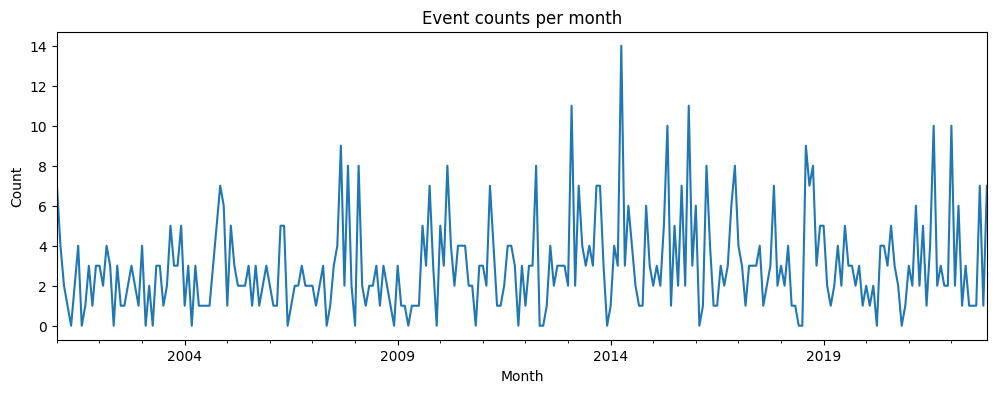

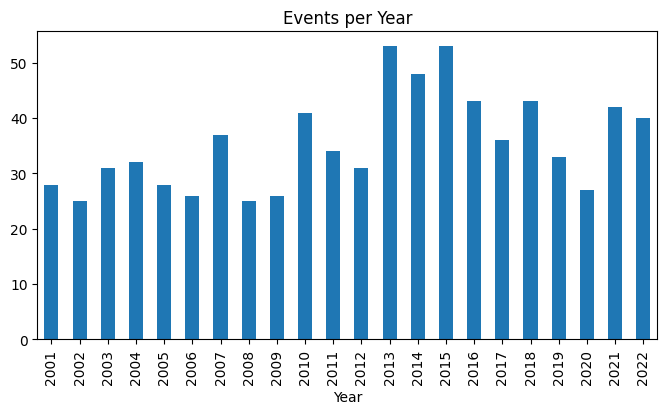

In [11]:

df['Year'] = df['Year'].astype(int)
df['Month'] = df['Month'].astype(int)

# create a datetime at month granularity
df['event_date'] = pd.to_datetime(df[['Year','Month']].assign(DAY=1))

# monthly counts and yearly counts
monthly_counts = df.groupby(pd.Grouper(key='event_date', freq='M')).size()
yearly_counts = df.groupby('Year').size()

print("Monthly range:", monthly_counts.index.min(), "to", monthly_counts.index.max())
display(monthly_counts.head())
display(yearly_counts.sort_index())

# plot
import matplotlib.pyplot as plt
plt.figure(figsize=(12,4))
monthly_counts.plot()
plt.title("Event counts per month")
plt.xlabel("Month")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(8,4))
yearly_counts.plot(kind='bar')
plt.title("Events per Year")
plt.show()


**Magnitude & depth, and outlier check**

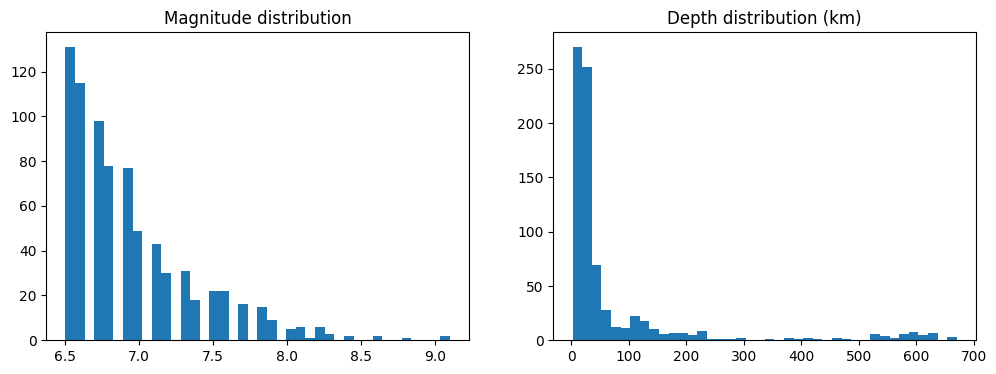

Magnitude min/max: 6.5 9.1


,magnitude,depth,latitude,longitude,tsunami
668,9.1,30.00,3.2950,95.9820,0
476,9.1,29.00,38.2970,142.3730,0
517,8.8,22.90,-36.1220,-72.8980,0
441,8.6,20.00,2.3270,93.0630,0
657,8.6,30.00,2.0850,97.1080,0
593,8.4,34.00,-4.4380,101.3670,0
767,8.4,33.00,-16.2650,-73.6410,0
614,8.3,10.00,46.5920,153.2660,0
285,8.3,22.44,-31.5729,-71.6744,1
393,8.3,598.10,54.8920,153.2210,1


Depth min/max: 2.7 670.81


,magnitude,depth,latitude,longitude,tsunami
163,7.9,670.810,-18.4743,179.3500,1
295,7.8,664.000,27.8386,140.4930,1
5,7.0,660.000,-26.0442,178.3810,1
6,6.8,630.379,-25.9678,178.3630,1
166,7.1,630.000,-11.0355,-70.8284,0
219,7.3,627.170,4.4782,122.6170,1
4,6.6,624.464,-25.5948,178.2780,1
392,6.7,624.000,52.2350,151.4440,1
89,6.9,624.000,-6.6704,123.4930,0
17,6.5,622.730,-9.0618,-71.1647,0


In [12]:

import matplotlib.pyplot as plt
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.hist(df['magnitude'].dropna(), bins=40)
plt.title('Magnitude distribution')

plt.subplot(1,2,2)
plt.hist(df['depth'].dropna(), bins=40)
plt.title('Depth distribution (km)')
plt.show()

# show extreme values
print("Magnitude min/max:", df['magnitude'].min(), df['magnitude'].max())
display(df.sort_values('magnitude', ascending=False)[['magnitude','depth','latitude','longitude','tsunami']].head(10))

print("Depth min/max:", df['depth'].min(), df['depth'].max())
display(df.sort_values('depth', ascending=False)[['magnitude','depth','latitude','longitude','tsunami']].head(10))


**correlation matrix & pairwise scatter (mag vs depth)**

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


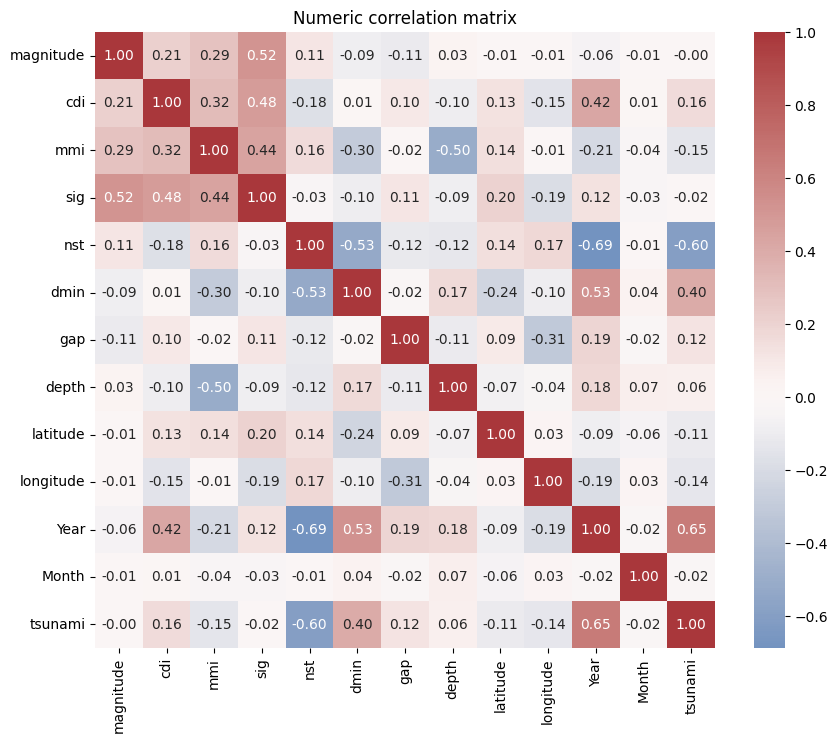

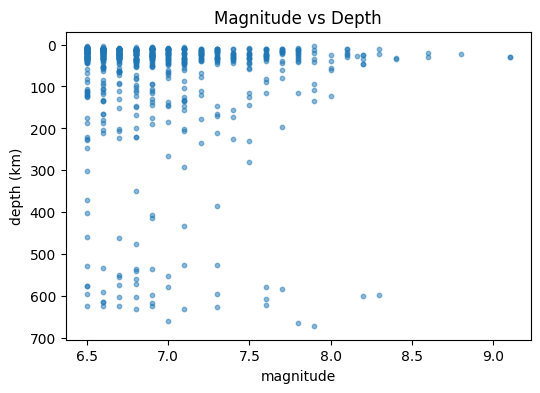

In [13]:

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[numeric_cols].corr()
import seaborn as sns
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Numeric correlation matrix")
plt.show()

# scatter: magnitude vs depth
plt.figure(figsize=(6,4))
plt.scatter(df['magnitude'], df['depth'], alpha=0.5, s=10)
plt.xlabel('magnitude'); plt.ylabel('depth (km)')
plt.title('Magnitude vs Depth')
plt.gca().invert_yaxis()  # depth increases downward - optional for interpretation
plt.show()


**spatial map of events colored by tsunami flag**

In [14]:
lat_col = 'latitude'
lon_col = 'longitude'
if lat_col in df.columns and lon_col in df.columns:
    import folium
    center = [df[lat_col].mean(), df[lon_col].mean()]
    m = folium.Map(location=center, zoom_start=2)
    # sample to keep map responsive
    sample = df.dropna(subset=[lat_col, lon_col]).sample(min(1500, len(df)), random_state=1)
    colormap = {0:'blue', 1:'red'}
    for _, r in sample.iterrows():
        color = colormap.get(int(r['tsunami']), 'gray')
        popup = f"mag: {r['magnitude']}, depth: {r['depth']}, tsunami: {int(r['tsunami'])}"
        folium.CircleMarker([r[lat_col], r[lon_col]], radius=3, color=color, fill=True, popup=popup).add_to(m)
    m.save('earthquake_tsunami_map.html')
    print("Saved elephant_map: earthquake_tsunami_map.html")
else:
    print("No lat/lon columns found.")


Saved elephant_map: earthquake_tsunami_map.html


**Simple tsunami risk score and inspect top events**

In [15]:
df_risk = df.copy()

def minmax(series):
    s = pd.to_numeric(series, errors='coerce')
    if s.dropna().empty or s.max()==s.min():
        return pd.Series(np.nan, index=s.index)
    return (s - s.min())/(s.max()-s.min())

# mag_score
df_risk['mag_score'] = minmax(df_risk['magnitude'])

# depth_score: shallower -> higher score
depth = pd.to_numeric(df_risk['depth'], errors='coerce')
df_risk['depth_score'] = minmax(depth.max() - depth)

# tsunami flag score (0/1)
df_risk['tsunami_flag_score'] = df_risk['tsunami'].fillna(0).astype(int)

# weights
w_mag, w_depth, w_flag = 0.6, 0.25, 0.15

num = (df_risk['mag_score'].fillna(0)*w_mag +
       df_risk['depth_score'].fillna(0)*w_depth +
       df_risk['tsunami_flag_score'].fillna(0)*w_flag)

avail = ((~df_risk['mag_score'].isna())*w_mag +
         (~df_risk['depth_score'].isna())*w_depth +
         (~df_risk['tsunami_flag_score'].isna())*w_flag)

df_risk['risk_score'] = num / avail.replace({0:np.nan})

def risk_cat(x):
    if pd.isna(x): return 'Unknown'
    if x < 0.25: return 'Low'
    if x < 0.5: return 'Moderate'
    if x < 0.75: return 'High'
    return 'Very High'

df_risk['risk_category'] = df_risk['risk_score'].apply(risk_cat)

# show top very high risk rows
display(df_risk.sort_values('risk_score', ascending=False).head(20)[['magnitude','depth','tsunami','risk_score','risk_category','latitude','longitude']])

# save
df_risk.to_csv('earthquake_risk_scores.csv', index=False)
print("Saved earthquake_risk_scores.csv")


,magnitude,depth,tsunami,risk_score,risk_category,latitude,longitude
476,9.1,29.00,0,0.840159,Very High,38.2970,142.3730
668,9.1,30.00,0,0.839785,Very High,3.2950,95.9820
285,8.3,22.44,1,0.807998,Very High,-31.5729,-71.6744
356,8.2,25.00,1,0.783963,Very High,-19.6097,-70.7691
60,8.2,35.00,1,0.780221,Very High,55.3154,-157.8290
59,8.2,46.66,1,0.775858,Very High,55.4742,-157.9170
198,8.2,47.39,1,0.775585,Very High,15.0222,-93.8993
517,8.8,22.90,0,0.773211,Very High,-36.1220,-72.8980
74,8.1,28.93,1,0.759416,Very High,-29.7466,-177.2240
414,8.0,24.00,1,0.738184,High,-10.7990,165.1140


Saved earthquake_risk_scores.csv


**Visualizations**

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (10,5)
sns.set_palette("Set2")


**Earthquake frequency over years/months**

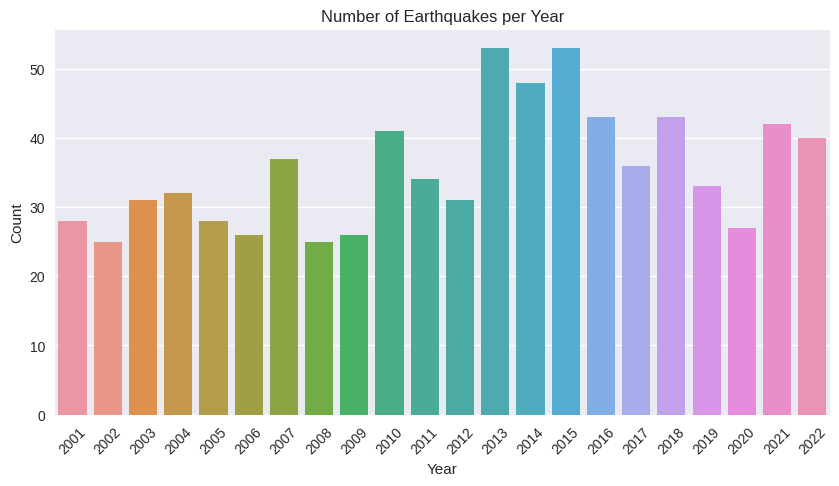

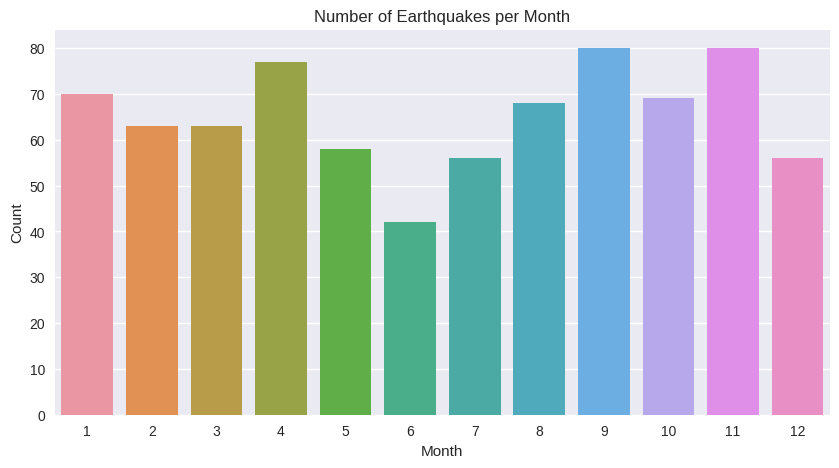

In [20]:
# Events per year
yearly_counts = df['Year'].value_counts().sort_index()
sns.barplot(x=yearly_counts.index, y=yearly_counts.values)
plt.title("Number of Earthquakes per Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Events per month
monthly_counts = df['Month'].value_counts().sort_index()
sns.barplot(x=monthly_counts.index, y=monthly_counts.values)
plt.title("Number of Earthquakes per Month")
plt.xlabel("Month")
plt.ylabel("Count")
plt.show()


**Magnitude distribution**

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


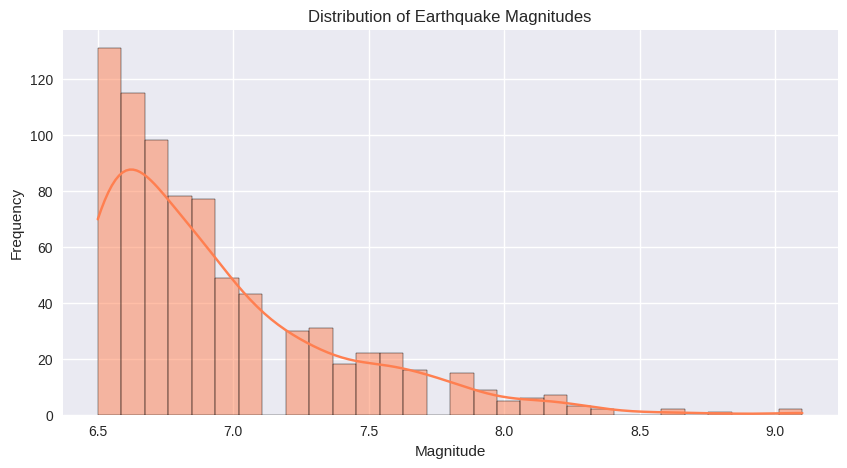

In [21]:
sns.histplot(df['magnitude'], bins=30, kde=True, color='coral')
plt.title("Distribution of Earthquake Magnitudes")
plt.xlabel("Magnitude")
plt.ylabel("Frequency")
plt.show()

**Depth distribution**

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


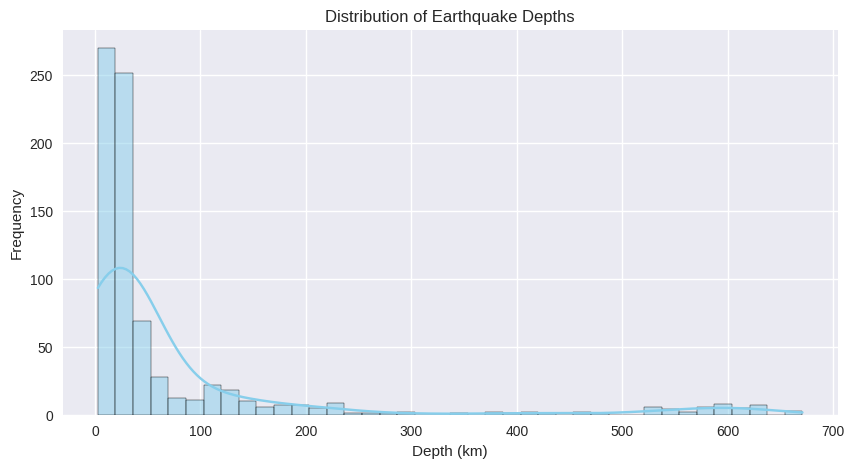

In [22]:
sns.histplot(df['depth'], bins=40, kde=True, color='skyblue')
plt.title("Distribution of Earthquake Depths")
plt.xlabel("Depth (km)")
plt.ylabel("Frequency")
plt.show()

**Tsunami vs. Non-Tsunami Comparison**

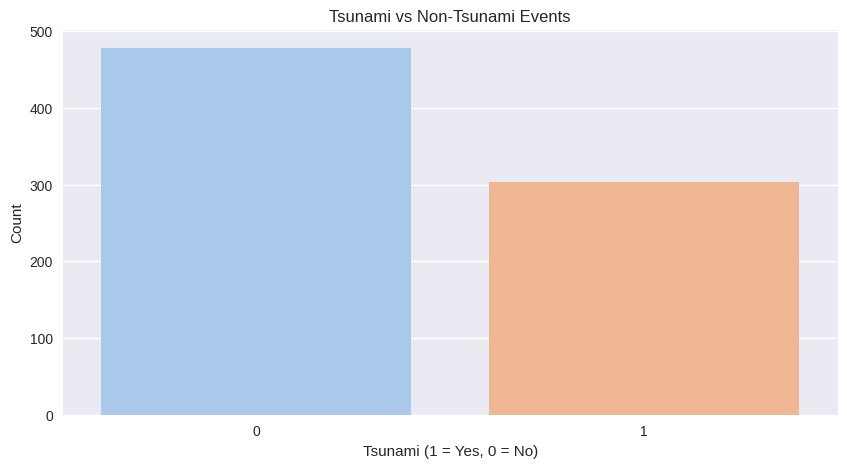

In [23]:
sns.countplot(x='tsunami', data=df, palette='pastel')
plt.title("Tsunami vs Non-Tsunami Events")
plt.xlabel("Tsunami (1 = Yes, 0 = No)")
plt.ylabel("Count")
plt.show()

**Magnitude by Tsunami**

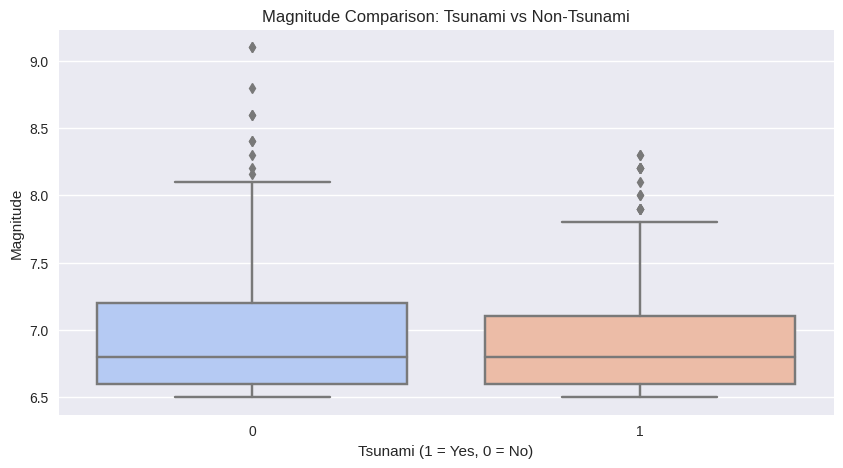

In [24]:
sns.boxplot(x='tsunami', y='magnitude', data=df, palette='coolwarm')
plt.title("Magnitude Comparison: Tsunami vs Non-Tsunami")
plt.xlabel("Tsunami (1 = Yes, 0 = No)")
plt.ylabel("Magnitude")
plt.show()

**Latitude vs Longitude (scatter map)**

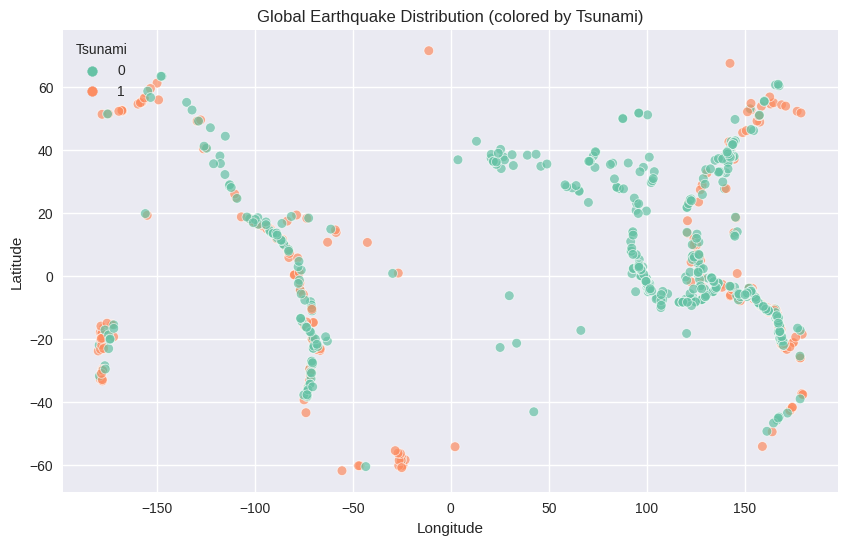

In [25]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='longitude', y='latitude', hue='tsunami', alpha=0.7)
plt.title("Global Earthquake Distribution (colored by Tsunami)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title='Tsunami')
plt.show()

**Magnitude vs Depth Scatter (with Tsunami hue)**

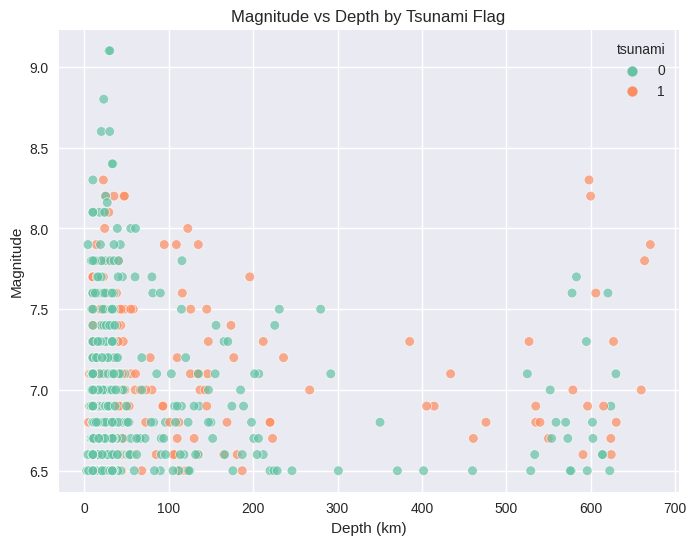

In [26]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='depth', y='magnitude', hue='tsunami', data=df, alpha=0.7)
plt.title("Magnitude vs Depth by Tsunami Flag")
plt.xlabel("Depth (km)")
plt.ylabel("Magnitude")
plt.show()

**Significance vs Magnitude**

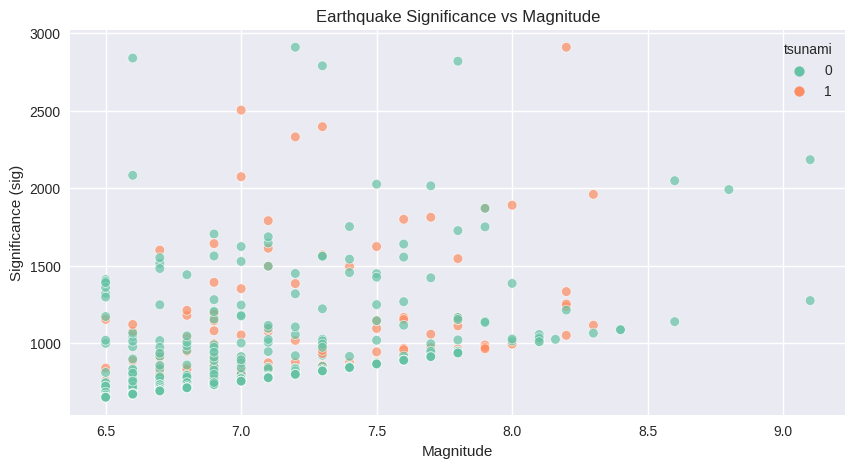

In [27]:
sns.scatterplot(x='magnitude', y='sig', hue='tsunami', data=df, alpha=0.7)
plt.title("Earthquake Significance vs Magnitude")
plt.xlabel("Magnitude")
plt.ylabel("Significance (sig)")
plt.show()


**Tsumani Prediction**

In [44]:

df = df.drop(['id', 'event_id'], axis=1, errors='ignore')


for col in df.select_dtypes(include='object').columns:
    try:
        df[col] = pd.to_datetime(df[col])
    except (ValueError, TypeError):
        pass 
for col in df.select_dtypes(include='datetime64[ns]').columns:
    df[f'{col}_year'] = df[col].dt.year
    df[f'{col}_month'] = df[col].dt.month
    df[f'{col}_day'] = df[col].dt.day
    df = df.drop(col, axis=1)


print("Null values per column:\n", df.isnull().sum())

# Drop or fill missing values
df = df.dropna()


#  Encoding categorical columns

df = pd.get_dummies(df, drop_first=True)



X = df.drop('tsunami', axis=1)
y = df['tsunami']




Null values per column:
 magnitude           0
cdi                 0
mmi                 0
sig                 0
nst                 0
dmin                0
gap                 0
depth               0
latitude            0
longitude           0
Year                0
Month               0
tsunami             0
event_date_year     0
event_date_month    0
event_date_day      0
dtype: int64


In [45]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Logistic Regression Model

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

# Predictions
y_pred = lr.predict(X_test)

#  Model Evaluation
# ==========================
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.80      0.85        96
           1       0.74      0.87      0.80        61

    accuracy                           0.83       157
   macro avg       0.82      0.84      0.82       157
weighted avg       0.84      0.83      0.83       157

Confusion Matrix:
 [[77 19]
 [ 8 53]]
ROC-AUC: 0.8354678961748634


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [46]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    class_weight='balanced',  # helps if tsunami=1 is less frequent
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

#  Evaluation

print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.91      0.95        96
           1       0.87      0.98      0.92        61

    accuracy                           0.94       157
   macro avg       0.93      0.94      0.93       157
weighted avg       0.94      0.94      0.94       157

Confusion Matrix:
 [[87  9]
 [ 1 60]]
ROC-AUC: 0.9643954918032787


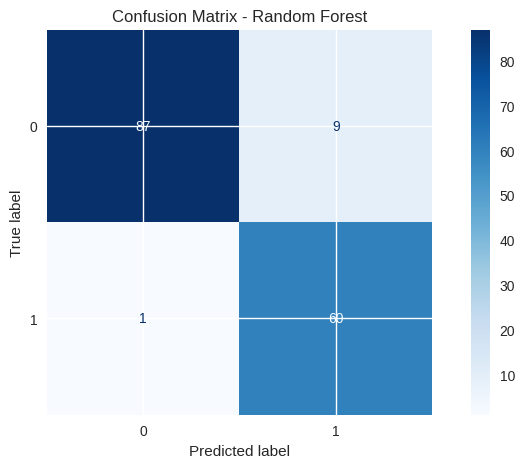

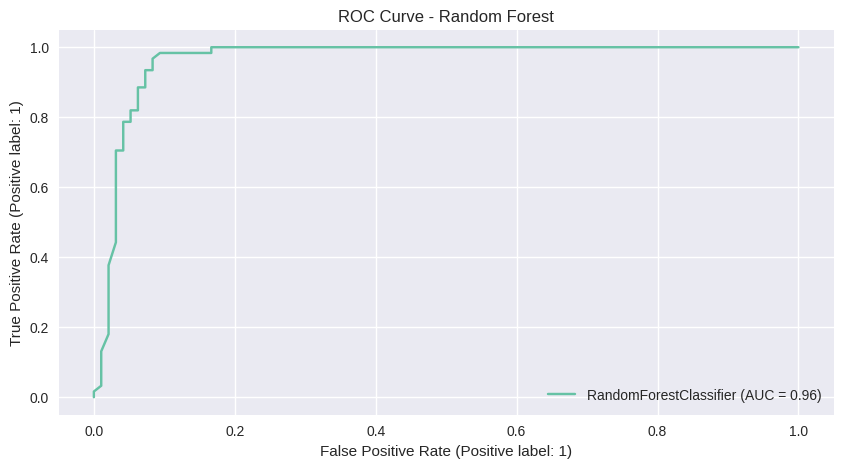

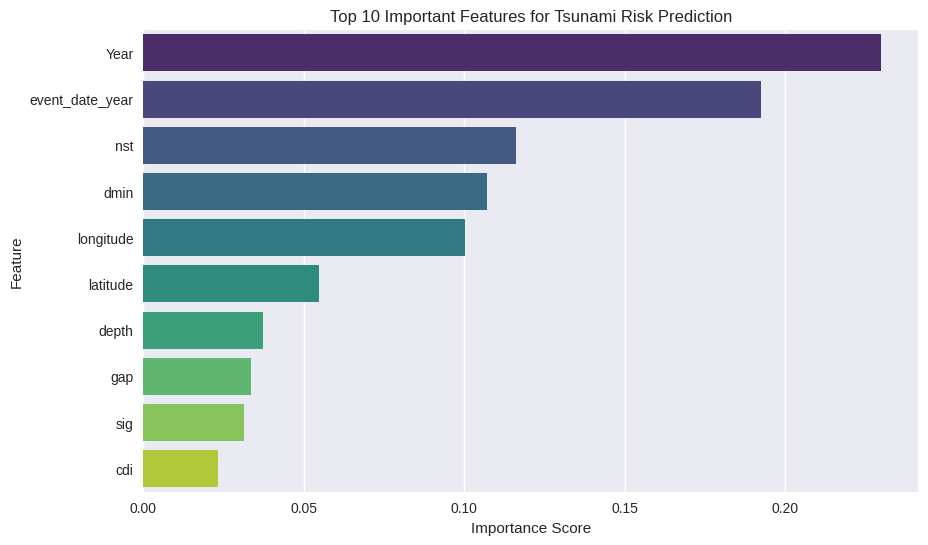

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay

# Confusion Matrix
ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test, cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.show()

# ROC Curve
RocCurveDisplay.from_estimator(rf, X_test, y_test)
plt.title("ROC Curve - Random Forest")
plt.show()

# Feature Importance
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=importances[:10], y=importances.index[:10], palette="viridis")
plt.title("Top 10 Important Features for Tsunami Risk Prediction")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()


**Predict new event**

In [50]:
import pandas as pd

# Creating a single sample with the same columns as X_train
new_event = pd.DataFrame([{
    'magnitude': 7.3,
    'depth': 25.0,
    'gap': 50,
    'latitude': -5.5,
    'longitude': 145.6,
    'sig': 720,
    'nst': 200,
    'mmi': 7,
    'cdi': 6,
    'Year': 2025,
    'Month': 11
    
}])

# Making sure columns match your training set exactly
new_event = new_event.reindex(columns=X_train.columns, fill_value=0)

# Predict tsunami risk
risk_pred = rf.predict(new_event)
risk_prob = rf.predict_proba(new_event)[:, 1]

print("Predicted Tsunami Risk (0 = No, 1 = Yes):", risk_pred[0])
print("Tsunami Probability Score:", round(risk_prob[0], 3))


Predicted Tsunami Risk (0 = No, 1 = Yes): 0
Tsunami Probability Score: 0.37


In [54]:
import pandas as pd

# Creating a single sample with the same columns as X_train
new_event = pd.DataFrame([{
    'magnitude': 8.1,
    'depth': 16.5,
    'gap': 35,
    'latitude': -7.5,
    'longitude': 180.5,
    'sig': 630,
    'nst': 215,
    'mmi': 6,
    'cdi': 5,
    'Year': 2025,
    'Month': 9
    
}])

# Making sure columns match your training set exactly
new_event = new_event.reindex(columns=X_train.columns, fill_value=0)

# Predict tsunami risk
risk_pred = rf.predict(new_event)
risk_prob = rf.predict_proba(new_event)[:, 1]

print("Predicted Tsunami Risk (0 = No, 1 = Yes):", risk_pred[0])
print("Tsunami Probability Score:", round(risk_prob[0], 3))


Predicted Tsunami Risk (0 = No, 1 = Yes): 0
Tsunami Probability Score: 0.375
